In [6]:
from collect import *
from extract import *
from run_tests import *
from additional_suite.entropy_estimator import min_entropy_nist_90b, calculate_safe_compression_ratio

In [14]:
collect(3_000_000, "data.bin", baud_rate=3000000)

Найден порт: COM3 - Устройство с последовательным интерфейсом USB (COM3)
Сбор 3,000,000 отсчетов... (Ctrl+C для остановки)
  Прогресс: 3,000,320/3,000,000 (100%)

Собрано: 3,000,000 отсчетов
Время сбора: 8.0 сек
Скорость: 374,559 отсчетов/сек
Файл сохранён: data.bin (Размер: 5.72 МБ)


In [15]:
raw_bits = load_data_bin("data.bin")

Загружено 3000000 отсчетов из data.bin.


In [16]:
diff_array = np.diff(raw_bits)
diff_bits = (diff_array & 1).astype(np.uint8)

min_entropy = min_entropy_nist_90b(diff_bits)
safe_compression_ratio = calculate_safe_compression_ratio(min_entropy)

print(f"\nМин-энтропия: {min_entropy:.4f} бит/бит")
print(f"Рекомендуемый коэффициент сжатия: ≤ {safe_compression_ratio:.2f}")

                      MCV: 0.9827 бит/символ  (0.168 сек)
                Collision: 1.0000 бит/символ  (0.219 сек)
                   Markov: 0.9730 бит/символ  (0.614 сек)
              Compression: 1.0000 бит/символ  (0.903 сек)
                  t-Tuple: 0.9673 бит/символ  (2.172 сек)
                 MultiMCW: 0.9974 бит/символ  (0.470 сек)
                      Lag: 0.9872 бит/символ  (0.038 сек)
                 MultiMMC: 0.9620 бит/символ  (4.139 сек)

             Мин-энтропия: 0.9620 бит/бит
              Общее время: 8.724 сек

Мин-энтропия: 0.9620 бит/бит
Рекомендуемый коэффициент сжатия: ≤ 2.16


In [22]:
_BYTE_TO_BITS = np.unpackbits(np.arange(256, dtype=np.uint8).reshape(-1, 1), bitorder='big').reshape(256, 8)


def arx_extract_optimized(raw_data, target_bits, compression_ratio=2):
    """
    Оптимизированная версия ARX-экстрактора с улучшенной диффузией
    """
    raw_array = np.asarray(raw_data, dtype=np.uint16)
    
    low_bits = (raw_array & 1).astype(np.uint8)
    high_bits = ((raw_array >> 8) & 1).astype(np.uint8)
    
    combined_bits = (low_bits ^ high_bits)  
    
    diff_bits = np.diff(combined_bits) & 1
    raw_bits = (np.diff(diff_bits) & 1).astype(np.uint8)
    
    input_block_bytes = 32
    output_bits = 256 // compression_ratio
    output_bytes = max(1, (output_bits + 7) // 8)
    
    n_blocks = min(
        len(raw_bits) // (input_block_bytes * 8),
        (target_bits + output_bytes * 8 - 1) // (output_bytes * 8)
    )
    
    if n_blocks == 0:
        return np.array([], dtype=np.int8)
    
    usable = raw_bits[:n_blocks * input_block_bytes * 8].reshape(n_blocks, input_block_bytes * 8)
    block_bytes = np.packbits(usable, axis=1, bitorder='big')
    
    result = bytearray(n_blocks * output_bytes)
    
    ARX_CONSTANTS = np.array([
        0x9E3779B97F4A7C15,  # φ
        0x6A09E667F3BCC908,  # √2
        0x243F6A8885A308D3,  # π
        0xB7E151628AED2A6A,  # e
        0xBB67AE8584CAA73B,  # √3
        0xB17217F7D1CF79AB,  # ln(2)
        0x33BA004F00621383,  # apery
        0x93C467E37DB0C7A4   # euler-maskeroni
    ], dtype=np.uint64)
    
    MASK64 = np.uint64(0xFFFFFFFFFFFFFFFF)
    
    # === IV: первые 4 константы (совпадают с размером state) ===
    prev_state = ARX_CONSTANTS[:4].copy()
    
    for i in range(n_blocks):
        state = np.frombuffer(bytes(block_bytes[i]), dtype=np.uint64).copy()
        
        # === Chaining: связывание с предыдущим блоком ===
        state ^= prev_state
        
        for round_idx in range(32):
            state ^= ARX_CONSTANTS[round_idx % 8]
            state = ((state << np.uint64(13)) | (state >> np.uint64(51))) & MASK64
            state[0] ^= state[1]
            state[2] ^= state[3]
            state[1] ^= state[2]
            state[3] ^= state[0]
            state = ((state << np.uint64(17)) | (state >> np.uint64(47))) & MASK64
        
        # Сохраняем ПОЛНОЕ состояние для следующего блока
        prev_state = state.copy()
        
        out_bytes = state.tobytes()[:output_bytes]
        result[i * output_bytes : (i + 1) * output_bytes] = out_bytes
    
    result_array = np.frombuffer(bytes(result), dtype=np.uint8)
    all_bits = _BYTE_TO_BITS[result_array].ravel()
    
    return all_bits[:target_bits].astype(np.int8)

In [23]:
extracted_bits = arx_extract_optimized(raw_bits, 1_000_000, 2)
run_nist(extracted_bits)

Длина последовательности: 1000000 бит
Распределение: 0.5000 (1) / 0.5000 (0)
----------------------------------------------------------------------
Название теста                                | P-value    | Статус
----------------------------------------------------------------------
1. Frequency (Monobit) Test                   | 0.923521   | Пройден
2. Block Frequency Test                       | 0.364214   | Пройден
3. Runs Test                                  | 0.281038   | Пройден
4. Longest Run of Ones in a Block             | 0.585982   | Пройден
5. Binary Matrix Rank Test                    | 0.617303   | Пройден
6. Spectral (DFT) Test                        | 0.994564   | Пройден
7. Non-overlapping Template (mean P)          | 0.574087   | Пройден
8. Overlapping Template Matching (m=9)        | 0.052398   | Пройден
9. Maurer's Universal Test                    | 0.364527   | Пройден
10. Linear Complexity Test                    | 0.104948   | Пройден
11. Serial Test (m=4)  

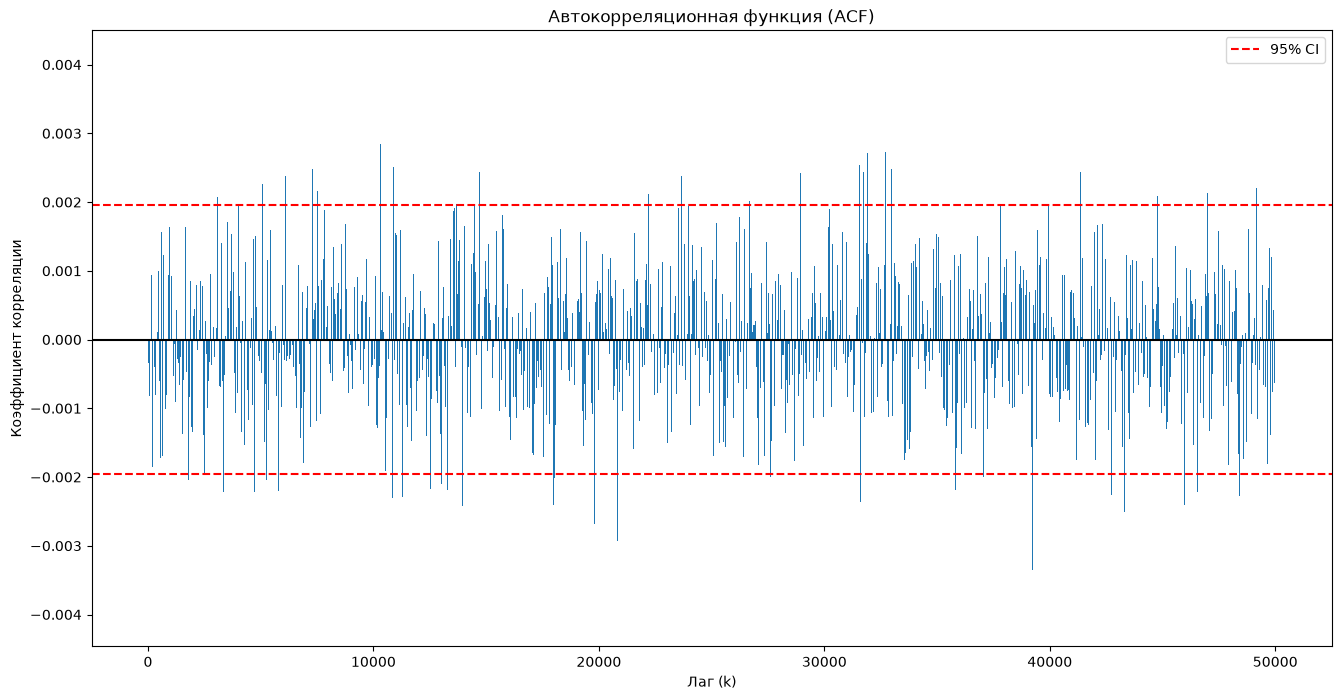

In [24]:
def plot_acf1(bits, max_lag=50):
    """Визуализация ACF"""
    bits = np.asarray(bits, dtype=int)
    X = 2 * bits - 1
    n = len(X)
    
    lags = range(1, max_lag + 1)
    acf = [np.dot(X[:n-k], X[k:]) / n for k in lags]
    
    plt.figure(figsize=(16, 8))
    plt.bar(lags, acf, width=0.8)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.axhline(y=1.96 / np.sqrt(n), color='red', linestyle='--', label='95% CI')
    plt.axhline(y=-1.96 / np.sqrt(n), color='red', linestyle='--')
    plt.title('Автокорреляционная функция (ACF)')
    plt.xlabel('Лаг (k)')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

plot_acf1(extracted_bits, 50000)